In [77]:
import numpy as np
import pandas as pd
from sklearn import set_config
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [78]:
# Output dataframes instead of arrays
set_config(transform_output="pandas")

penguins = pd.read_csv("01_materials/notebooks/dataset/penguins.csv")
penguins

,bill_length_mm,flipper_length_mm
0,39.1,181
1,39.5,186
2,40.3,195
3,36.7,193
4,39.3,190
...,...,...
337,55.8,207
338,43.5,202
339,49.6,193
340,50.8,210


In [79]:
min_max_values = penguins.agg(['min', 'max'])
min_max_values


,bill_length_mm,flipper_length_mm
min,32.1,172
max,59.6,231


In [80]:
penguins_copy = penguins.copy()

scaler = StandardScaler()
standardized_penguins = scaler.fit_transform(penguins_copy)

# Convert the standardized data back to a DataFrame
standardized_penguins = pd.DataFrame(standardized_penguins, columns=standardized_penguins.columns)

standardized_penguins


,bill_length_mm,flipper_length_mm
0,-0.884499,-1.418347
1,-0.811126,-1.062250
2,-0.664380,-0.421277
3,-1.324737,-0.563715
4,-0.847812,-0.777373
...,...,...
337,2.178824,0.433355
338,-0.077396,0.077258
339,1.041543,-0.563715
340,1.261662,0.647013


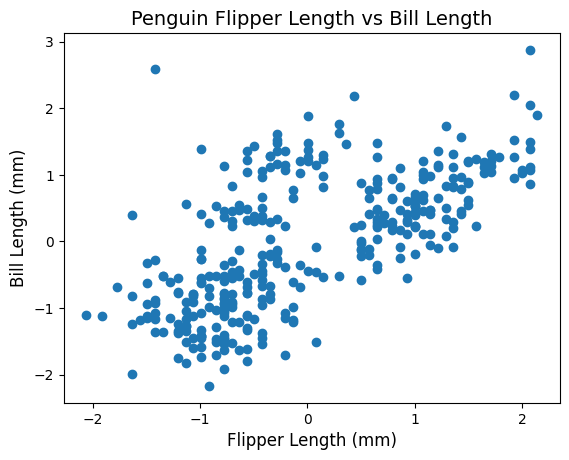

In [81]:
# Scatter plot for bill_length_mm vs flipper_length_mm
plt.scatter(standardized_penguins['flipper_length_mm'], standardized_penguins['bill_length_mm'])

# Adding labels and title
plt.title('Penguin Flipper Length vs Bill Length', fontsize=14)
plt.ylabel('Bill Length (mm)', fontsize=12)
plt.xlabel('Flipper Length (mm)', fontsize=12)

# Display the plot
plt.show()

In [82]:
# perform kmeans clurstering

#step 1. initailize our model 

kmeans = KMeans(n_clusters= 5, random_state=123, n_init=10)

#for now we assume k=5,n_init = 10 means the model is running 10 times

In [83]:
# step 2. fit model to data

clusters = kmeans.fit(standardized_penguins)

# we are not splitting the data into train/test because this is unsupervised data.  

In [84]:
clusters.labels_

#there is are 5 labels: 0,1,2,3,4

array([1, 1, 4, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 1, 4, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1,
       1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 1, 1, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 1, 4, 1, 1, 1,
       1, 1, 4, 1, 1, 1, 2, 1, 4, 1, 4, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1,
       1, 1, 4, 1, 4, 1, 1, 4, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 2, 3, 2,
       3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 3, 3, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2,
       3, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 3, 3, 0, 3, 3, 3, 2, 3, 2, 2, 2, 3, 2, 2, 3, 3, 2,
       3, 2, 3, 2, 3, 2, 2, 3, 2, 3, 4, 0, 0, 4, 0, 4, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 0, 0, 4, 0, 4, 0, 4, 0, 4, 0, 0,

In [85]:
#copy the standadrized data frame

standardized_penguins_with_clusters = standardized_penguins.copy()

#add cluster labes back to data set 
standardized_penguins_with_clusters["Cluster"] = clusters.labels_
standardized_penguins_with_clusters


#Now see the data with the clusters

,bill_length_mm,flipper_length_mm,Cluster
0,-0.884499,-1.418347,1
1,-0.811126,-1.062250,1
2,-0.664380,-0.421277,4
3,-1.324737,-0.563715,1
4,-0.847812,-0.777373,1
...,...,...,...
337,2.178824,0.433355,0
338,-0.077396,0.077258,4
339,1.041543,-0.563715,0
340,1.261662,0.647013,0


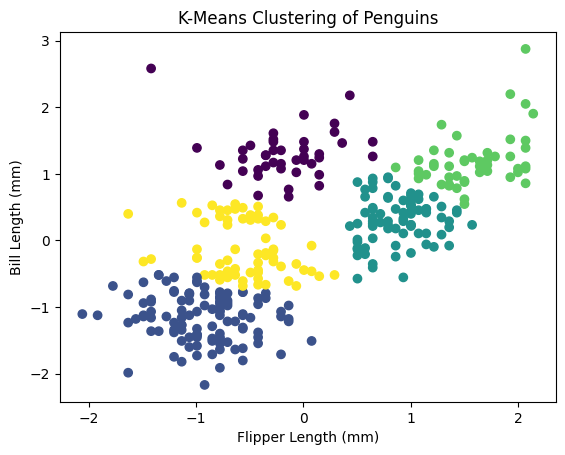

In [86]:
# Plot the clusters
plt.scatter(standardized_penguins_with_clusters['flipper_length_mm'], standardized_penguins_with_clusters['bill_length_mm'], c=standardized_penguins_with_clusters['Cluster'])
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.title('K-Means Clustering of Penguins')
plt.show()

In [87]:
kmeans.inertia_ # total WSSD


# how tight the data points are around the centroids. we need to look at how this value to other k values
#lower value = tighely grouped, higher number = more losely grouped

91.47610853298525

In [88]:
#intialzie empty data frame, with two things. Values of K and the WSSD for each

penguin_cluster_ks = pd.DataFrame(columns = ["k", "total_wssd"])

# going to use a loop

for k in range (1, 11): #going always the ways up to 10
    elbow_kmeans = KMeans(n_clusters=k, random_state=123, n_init=10) #intilaize the model
    elbow_kmeans.fit (standardized_penguins) # fit model to data 
    current_k = pd.DataFrame({"k": [k], "total_wssd": elbow_kmeans.inertia_})
    penguin_cluster_ks = pd.concat([penguin_cluster_ks, current_k], ignore_index=True)


/var/folders/hd/z6426f555y14_dvt50crlt5r0000gn/T/ipykernel_22263/1589666073.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  penguin_cluster_ks = pd.concat([penguin_cluster_ks, current_k], ignore_index=True)


In [89]:
penguin_cluster_ks

,k,total_wssd
0,1,684.000000
1,2,247.016625
2,3,157.815322
3,4,118.766244
4,5,91.476109
5,6,78.716593
6,7,66.722277
7,8,57.914115
8,9,52.458720
9,10,48.642403


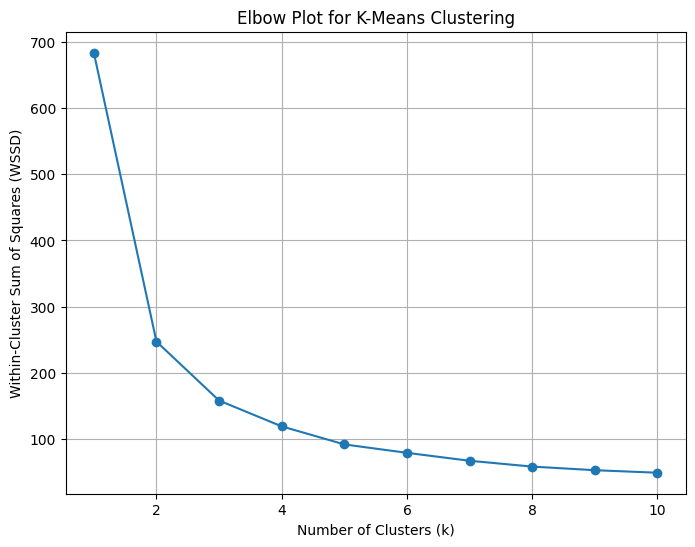

In [90]:
# Create the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(penguin_cluster_ks['k'], penguin_cluster_ks['total_wssd'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSSD)')
plt.title('Elbow Plot for K-Means Clustering')
plt.grid(True)
plt.show()

At this time, you can go back and change the clusters to 3, and do redo the steps and the plotting. 

Class No. 2 Jan 7


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
# Load the Airbnb listings dataset from a CSV file
airbnb = pd.read_csv("01_materials/notebooks/dataset/listings.csv")

In [93]:
# Calculate and return the average price from the "price" column in the Airbnb dataset
airbnb["price"].mean()

np.float64(249.16526273565984)

In [94]:
# #np. random see (100)
airbnb.sample(n=40)["price"].mean()

np.float64(256.3)

In [95]:
sample_list =[] #create an empty list
for i in range(20_000):  #default would be zero and max is 19,999
    sample = airbnb.sample (n = 40)
    sample = sample.assign (replicate = i) # all 40 listing will have same i, and next group will have the same i and so on.
    sample_list.append(sample) # append to the empty list  


In [96]:
# concante the data into a list
samples = pd.concat(sample_list)
samples

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
3730,7.860000e+17,Dunbar Southlands,Entire home/apt,1,1.0,1.0,1.0,289,0
801,2.009586e+07,Riley Park,Entire home/apt,2,1.0,1.0,1.0,110,0
2943,6.090000e+17,Kitsilano,Entire home/apt,2,1.0,1.0,1.0,217,0
2932,6.040000e+17,West End,Entire home/apt,2,1.0,1.0,1.0,215,0
2112,4.380704e+07,Downtown,Entire home/apt,2,1.0,1.0,1.0,166,0
...,...,...,...,...,...,...,...,...,...
1557,3.448374e+07,Downtown,Entire home/apt,4,1.0,1.0,3.0,140,19999
4198,8.830000e+17,Sunset,Entire home/apt,2,1.0,1.0,1.0,357,19999
2764,5.419455e+07,West End,Private room,2,1.0,1.0,0.0,203,19999
4775,9.650000e+17,Hastings-Sunrise,Entire home/apt,4,1.0,2.0,4.0,635,19999


In [97]:
#compute the mean for each replicate sample 
sample_estimates = samples.groupby("replicate")["price"].mean().reset_index(name = "sample_mean")

In [98]:
sample_estimates

,replicate,sample_mean
0,0,201.775
1,1,253.950
2,2,287.925
3,3,329.275
4,4,292.525
...,...,...
19995,19995,208.575
19996,19996,272.725
19997,19997,214.775
19998,19998,164.200


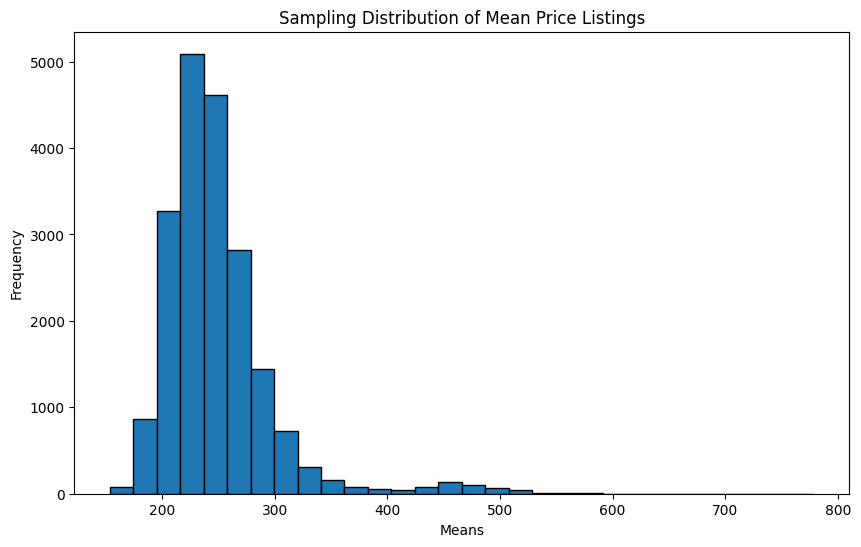

In [99]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(sample_estimates['sample_mean'], bins=30, edgecolor='black')

# Add titles and labels
plt.title('Sampling Distribution of Mean Price Listings')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [100]:
#bootstrapping

np.random.seed(1234)
one_sample =airbnb.sample (n=40)
one_sample

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
2912,5.970000e+17,Riley Park,Entire home/apt,9,3.0,4.0,5.0,214
787,1.986261e+07,Mount Pleasant,Entire home/apt,9,2.0,3.0,3.0,109
2696,5.333958e+07,Arbutus Ridge,Entire home/apt,3,1.0,1.0,0.0,200
3017,6.310000e+17,West End,Entire home/apt,2,1.0,1.0,0.0,223
1226,2.745958e+07,Downtown,Entire home/apt,1,NaN,1.0,NaN,126
2620,5.255417e+07,Downtown Eastside,Entire home/apt,4,1.0,1.0,2.0,198
4883,9.790000e+17,Downtown Eastside,Entire home/apt,7,2.0,3.0,4.0,834
608,1.554257e+07,Kitsilano,Entire home/apt,5,1.0,2.0,3.0,99
1400,3.124019e+07,Arbutus Ridge,Private room,2,1.0,1.0,2.0,133
149,3.100878e+06,Downtown,Entire home/apt,2,1.0,1.0,0.0,60


In [101]:
one_sample["price"].mean()

np.float64(219.85)

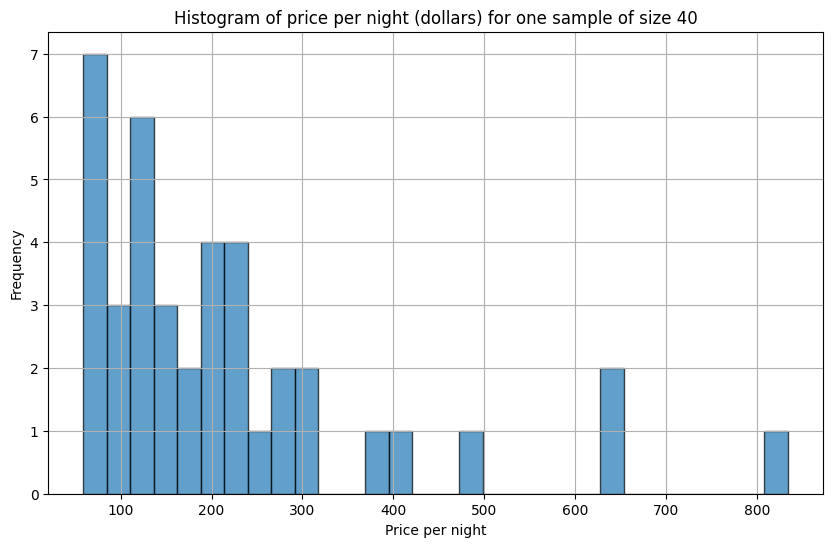

In [102]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(one_sample['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [103]:
boot1 = one_sample.sample(frac =1, replace = True)

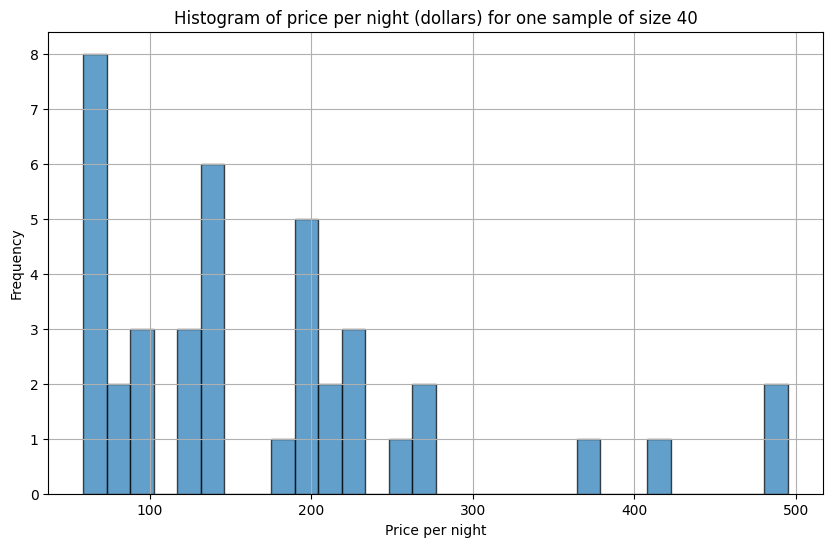

In [104]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(boot1['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [120]:
bookstrap_samples = [] #initalize an empty list
for i in range(20_000):
    sample = one_sample.sample (frac =1, replace = True)
    sample = sample.assign(replicate = i)
    bookstrap_samples.append(sample)

In [122]:
boot20000 = pd.concat(bookstrap_samples) 


In [126]:
#compute the mean for each replicate sample 
boot_means = boot20000.groupby("replicate")["price"].mean().reset_index(name = "mean_price")
boot_means

,replicate,mean_price
0,0,237.275
1,1,237.625
2,2,216.550
3,3,226.850
4,4,240.025
...,...,...
19995,19995,282.925
19996,19996,240.225
19997,19997,247.900
19998,19998,178.025


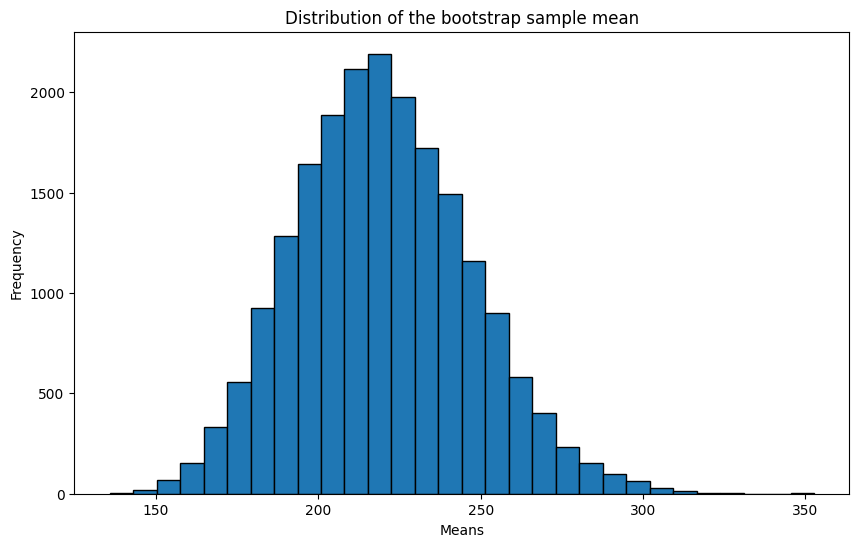

In [127]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_price'], bins=30, edgecolor='black')

# Add titles and labels
plt.title('Distribution of the bootstrap sample mean')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [129]:
#condicen interval
boot_means["mean_price"].quantile([0.025, 0.975])

0.025    170.725
0.975    275.875
Name: mean_price, dtype: float64